Best Parameters:
{'max_depth': None, 'n_estimators': 200}

Best Cross Validation R²:
0.9961786426944856

Best Model:
RandomForestRegressor(n_estimators=200, random_state=42)

Random Forest After Hyperparameter Tuning
-----------------------------------------
MAE : 3.80789400921659
RMSE: 8.040291081646032
R² Score: 0.9979409523119781
Model and scaler saved successfully!
                          Feature  Importance
6        Session_Duration (hours)    0.366100
13                   HR_Intensity    0.323533
14                  Effective_MET    0.141512
1                     Weight (kg)    0.129959
12                       Base_MET    0.019691
17             Workout_Type_Mixed    0.008681
16              Workout_Type_HIIT    0.005979
19              Workout_Type_Yoga    0.002116
8           Water_Intake (liters)    0.000400
11                            BMI    0.000398
7                  Fat_Percentage    0.000269
2                      Height (m)    0.000260
5                     Resting_

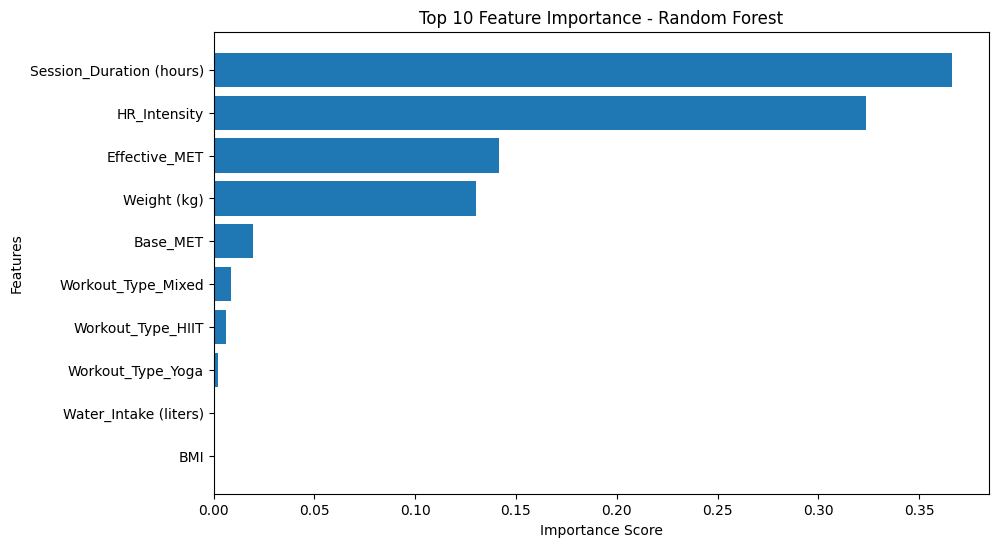

In [3]:
# ==========================================
# Hyperparameter Tuning - Random Forest
# ==========================================

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# ==========================================
# Load Dataset
# ==========================================

df = pd.read_csv("../data/Fitbit_dataset.csv")

# Remove unwanted column
df.drop(columns=["Unnamed: 0"], inplace=True)

# Rename target column
df.rename(
    columns={"Calories_Burned (kcal)": "Calories_Burned"},
    inplace=True
)

# ==========================================
# Separate Features and Target
# ==========================================

x = df.drop(columns=["Calories_Burned"])
y = df["Calories_Burned"]

# ==========================================
# Outlier Capping (IQR Method)
# ==========================================

numerical_columns = x.select_dtypes(include=["number"]).columns

for column in numerical_columns:

    Q1 = x[column].quantile(0.25)
    Q3 = x[column].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    x[column] = x[column].clip(lower=lower, upper=upper)

# ==========================================
# One Hot Encoding
# ==========================================

x = pd.get_dummies(
    x,
    columns=["Gender", "Workout_Type"],
    drop_first=True
)

# ==========================================
# Train-Test Split
# ==========================================

x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.2,
    random_state=42
)

# ==========================================
# Feature Scaling
# ==========================================

scaler = StandardScaler()

x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

# ==========================================
# Random Forest Model
# ==========================================

rf = RandomForestRegressor(random_state=42)

# ==========================================
# Hyperparameter Grid
# ==========================================

param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [10, None]
}

# ==========================================
# Grid Search CV
# ==========================================

grid = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=3,
    scoring="r2",
    n_jobs=-1
)

# ==========================================
# Train Grid Search
# ==========================================

grid.fit(x_train, y_train)

# ==========================================
# Best Parameters
# ==========================================

print("Best Parameters:")
print(grid.best_params_)

print("\nBest Cross Validation R²:")
print(grid.best_score_)

best_rf = grid.best_estimator_

print("\nBest Model:")
print(best_rf)

# ==========================================
# Prediction
# ==========================================

y_pred = best_rf.predict(x_test)

# ==========================================
# Evaluation
# ==========================================

mae = mean_absolute_error(y_test, y_pred)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))

r2 = r2_score(y_test, y_pred)

print("\nRandom Forest After Hyperparameter Tuning")
print("-----------------------------------------")
print("MAE :", mae)
print("RMSE:", rmse)
print("R² Score:", r2)

import joblib

# Save the trained Random Forest model
joblib.dump(best_rf, "../models/best_random_forest_model.pkl")

# Save the scaler used for preprocessing
joblib.dump(scaler, "../models/scaler.pkl")

print("Model and scaler saved successfully!")

# ==========================================
# Feature Importance
# ==========================================

feature_importance = best_rf.feature_importances_

feature_names = x.columns

importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": feature_importance
})

importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
)

print(importance_df)

# Top 10 Most Important Features
top_features = importance_df.head(10)

# Save feature importance
importance_df.to_csv(
    "../output/feature_importance.csv",
    index=False
)

# Plot
plt.figure(figsize=(10,6))

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.title("Top 10 Feature Importance - Random Forest")
plt.xlabel("Importance Score")
plt.ylabel("Features")

plt.gca().invert_yaxis()

plt.show()